In [2]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from scripts.exploratory_analysis import (
    load_data,
    save_plot,
    normalize_country
)

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

Data Loading

We load two datasets:

- **BLI (Better Life Index 2024)** -> socio-economic indicators
- **WHR (World Happiness Report 2024)** -> happiness metrics

These datasets will later be compared and potentially merged.

In [3]:
bli_raw, whr_raw = load_data()

bli = bli_raw.copy()
whr = whr_raw.copy()

print(f"BLI shape: {bli.shape}, WHR shape: {whr.shape}")

BLI shape: (38, 26), WHR shape: (143, 11)


Different datasets sometimes use different country names. We compare the country lists to identify mismatches.

In [3]:
bli_countries = set(bli["Country"].unique())
whr_countries = set(whr["Country name"].unique())

only_in_bli = bli_countries - whr_countries
print("Only in BLI:", only_in_bli)

Only in BLI: {'Korea', 'Türkiye', 'Slovak Republic'}


In [4]:
# Normalize country names
bli["Country name"] = bli["Country"].apply(normalize_country)

# Move "Country name" to the first column
cols = ["Country name"] + [c for c in bli.columns if c not in ["Country name", "Country"]]
bli = bli[cols]

# Remove extra spaces from column names
bli.columns = bli.columns.str.strip()

bli.head()

,Country name,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,Personal earnings,Quality of support network,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Stakeholder engagement for developing regulations,Voter turnout,Life expectancy,Self-reported health,Feeling safe walking alone at night,Homicide rate,Employees working very long hours,Time devoted to leisure and personal care,Life satisfaction
0,Australia,66589,NaN,19.4,NaN,37433.0,528768.0,3.1,73,1.0,55206.0,93,84.0,499.0,20.0,6.7,92,2.7,92,83.0,85,67,0.9,12.5,14.36,7.1
1,Austria,59225,0.8,20.8,1.6,37001.0,309637.0,2.3,72,1.3,53132.0,92,86.0,491.0,17.0,12.2,92,1.3,76,82.0,71,86,0.5,5.3,14.51,7.2
2,Belgium,55536,0.7,20.0,2.1,34884.0,447607.0,2.4,65,2.3,54327.0,90,80.0,500.0,19.0,12.8,79,2.0,88,82.1,74,56,1.1,4.3,15.52,6.8
3,Canada,54866,0.2,22.9,2.6,34421.0,478240.0,3.8,70,0.5,55342.0,93,92.0,517.0,17.0,7.1,90,2.9,68,82.1,89,78,1.2,3.3,14.57,7.0
4,Chile,16616,9.4,18.4,1.9,NaN,135787.0,7.0,56,NaN,26729.0,88,67.0,438.0,17.0,23.4,62,1.3,47,80.6,60,41,2.4,7.7,NaN,6.2


In [5]:
bli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 26 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Country name                                       38 non-null     object 
 1   GDP per capita (USD)                               38 non-null     int64  
 2   Dwellings without basic facilities                 35 non-null     float64
 3   Housing expenditure                                35 non-null     float64
 4   Rooms per person                                   37 non-null     float64
 5   Household net adjusted disposable income           33 non-null     float64
 6   Household net wealth                               29 non-null     float64
 7   Labour market insecurity                           34 non-null     float64
 8   Employment rate                                    38 non-null     int64  
 9   Long-term un

We examine missing values in each column to determine whether imputation or feature removal is necessary.

In [ ]:
missing_percent = (bli.isnull().sum() / len(bli)) * 100
print("Missing values (%)")
print(missing_percent)

Missing values (%)
Country name                                          0.000000
GDP per capita (USD)                                  0.000000
Dwellings without basic facilities                    7.894737
Housing expenditure                                   7.894737
Rooms per person                                      2.631579
Household net adjusted disposable income             13.157895
Household net wealth                                 23.684211
Labour market insecurity                             10.526316
Employment rate                                       0.000000
Long-term unemployment rate                           2.631579
Personal earnings                                     7.894737
Quality of support network                            0.000000
Educational attainment                                2.631579
Student skills                                        2.631579
Years in education                                    2.631579
Air pollution                       

The variable **"Time devoted to leisure and personal care"** contains more than 40% missing values. To avoid introducing bias through heavy imputation, this feature is removed from the dataset.

In [7]:
bli = bli.drop(columns=['Time devoted to leisure and personal care'])

In [8]:
bli.describe()

,GDP per capita (USD),Dwellings without basic facilities,Housing expenditure,Rooms per person,Household net adjusted disposable income,Household net wealth,Labour market insecurity,Employment rate,Long-term unemployment rate,Personal earnings,Quality of support network,Educational attainment,Student skills,Years in education,Air pollution,Water quality,Stakeholder engagement for developing regulations,Voter turnout,Life expectancy,Self-reported health,Feeling safe walking alone at night,Homicide rate,Employees working very long hours,Life satisfaction
count,38.000000,35.000000,35.000000,37.000000,33.000000,29.000000,34.000000,38.000000,37.000000,35.000000,38.000000,37.000000,37.000000,37.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,36.000000,38.000000
mean,48139.184211,3.051429,20.494286,1.675676,30490.151515,323959.620690,5.182353,68.657895,1.737838,43783.571429,91.078947,79.027027,486.459459,17.567568,13.207895,84.526316,2.150000,69.105263,80.984211,68.605263,73.842105,2.563158,7.202778,6.686842
std,28940.558500,5.373977,2.502580,0.413928,8184.496163,185528.628032,4.300280,7.591874,1.918094,13953.095782,5.424577,14.837053,29.322531,1.405160,6.153548,8.949519,0.580191,12.513321,2.571836,13.120109,12.979248,5.661316,7.269171,0.665835
min,7327.000000,0.000000,14.700000,1.000000,16269.000000,79245.000000,1.000000,48.000000,0.000000,16230.000000,77.000000,42.000000,406.000000,14.000000,5.500000,62.000000,1.200000,45.000000,75.100000,34.000000,41.000000,0.200000,0.300000,4.900000
25%,26553.000000,0.200000,18.650000,1.400000,24590.000000,188627.000000,2.625000,65.250000,0.800000,31265.500000,89.000000,76.000000,477.000000,17.000000,7.925000,80.250000,1.725000,62.250000,79.000000,62.750000,69.500000,0.500000,2.425000,6.200000
50%,43469.500000,0.500000,20.600000,1.700000,29488.000000,294735.000000,3.900000,70.000000,1.200000,45269.000000,93.000000,84.000000,495.000000,18.000000,12.100000,85.000000,2.150000,68.000000,81.900000,71.500000,77.000000,0.800000,4.400000,6.750000
75%,59051.000000,3.000000,21.800000,1.900000,34984.000000,370341.000000,5.775000,74.000000,2.200000,54766.500000,95.000000,89.000000,503.000000,18.000000,17.000000,91.000000,2.575000,77.750000,82.900000,75.750000,82.750000,1.275000,10.500000,7.275000
max,131384.000000,25.900000,27.400000,2.600000,51147.000000,941162.000000,21.700000,80.000000,10.800000,69392.000000,98.000000,94.000000,526.000000,20.000000,27.300000,98.000000,3.200000,92.000000,84.400000,89.000000,93.000000,26.800000,27.000000,7.900000


This histogram shows how life satisfaction scores are distributed across countries in the dataset.

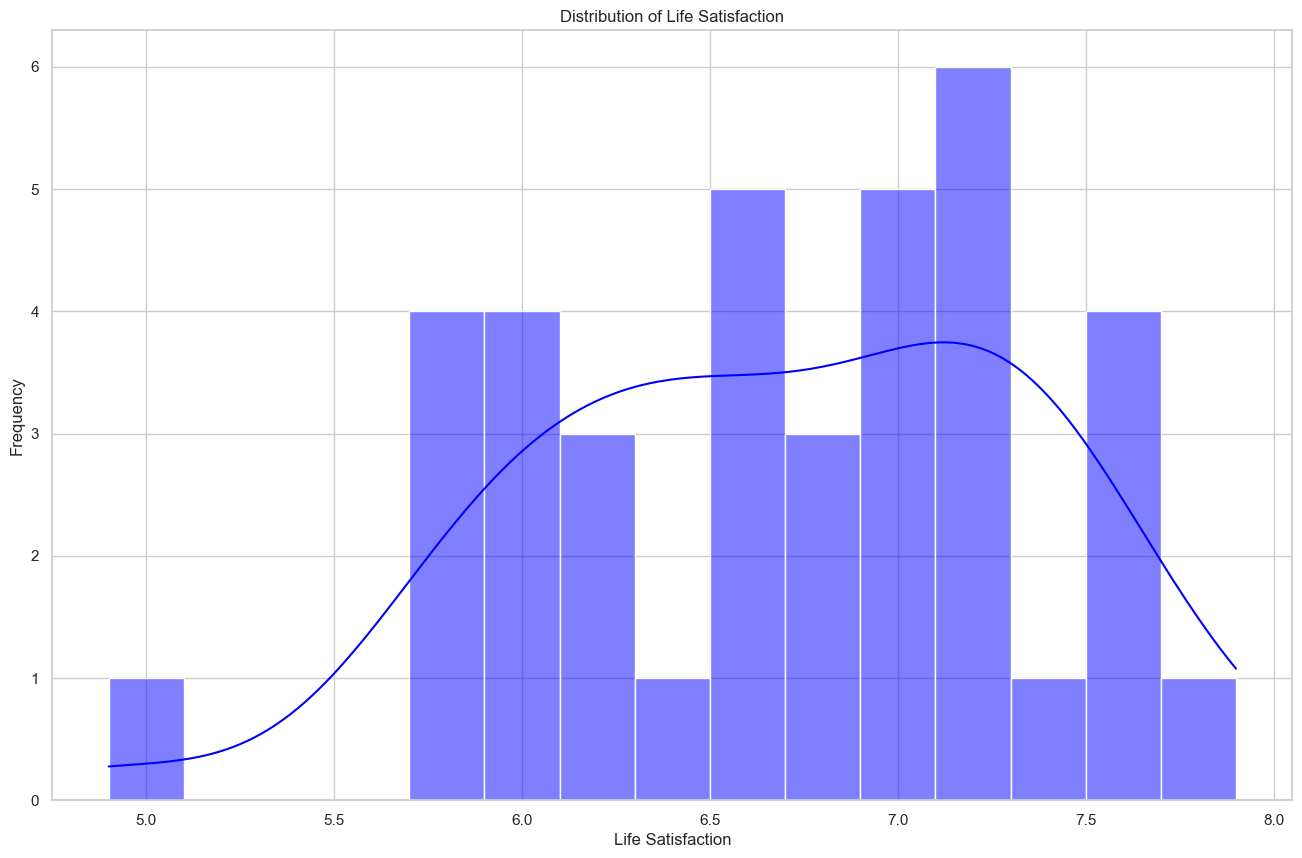

In [10]:
plt.figure(figsize=(16, 10))
sns.histplot(bli["Life satisfaction"], bins=15, kde=True, color="blue")
plt.title("Distribution of Life Satisfaction")
plt.xlabel("Life Satisfaction")
plt.ylabel("Frequency")
save_plot("life_satisfaction_distribution")
plt.show()

We compute the correlation matrix to identify which variables are most strongly associated with life satisfaction.

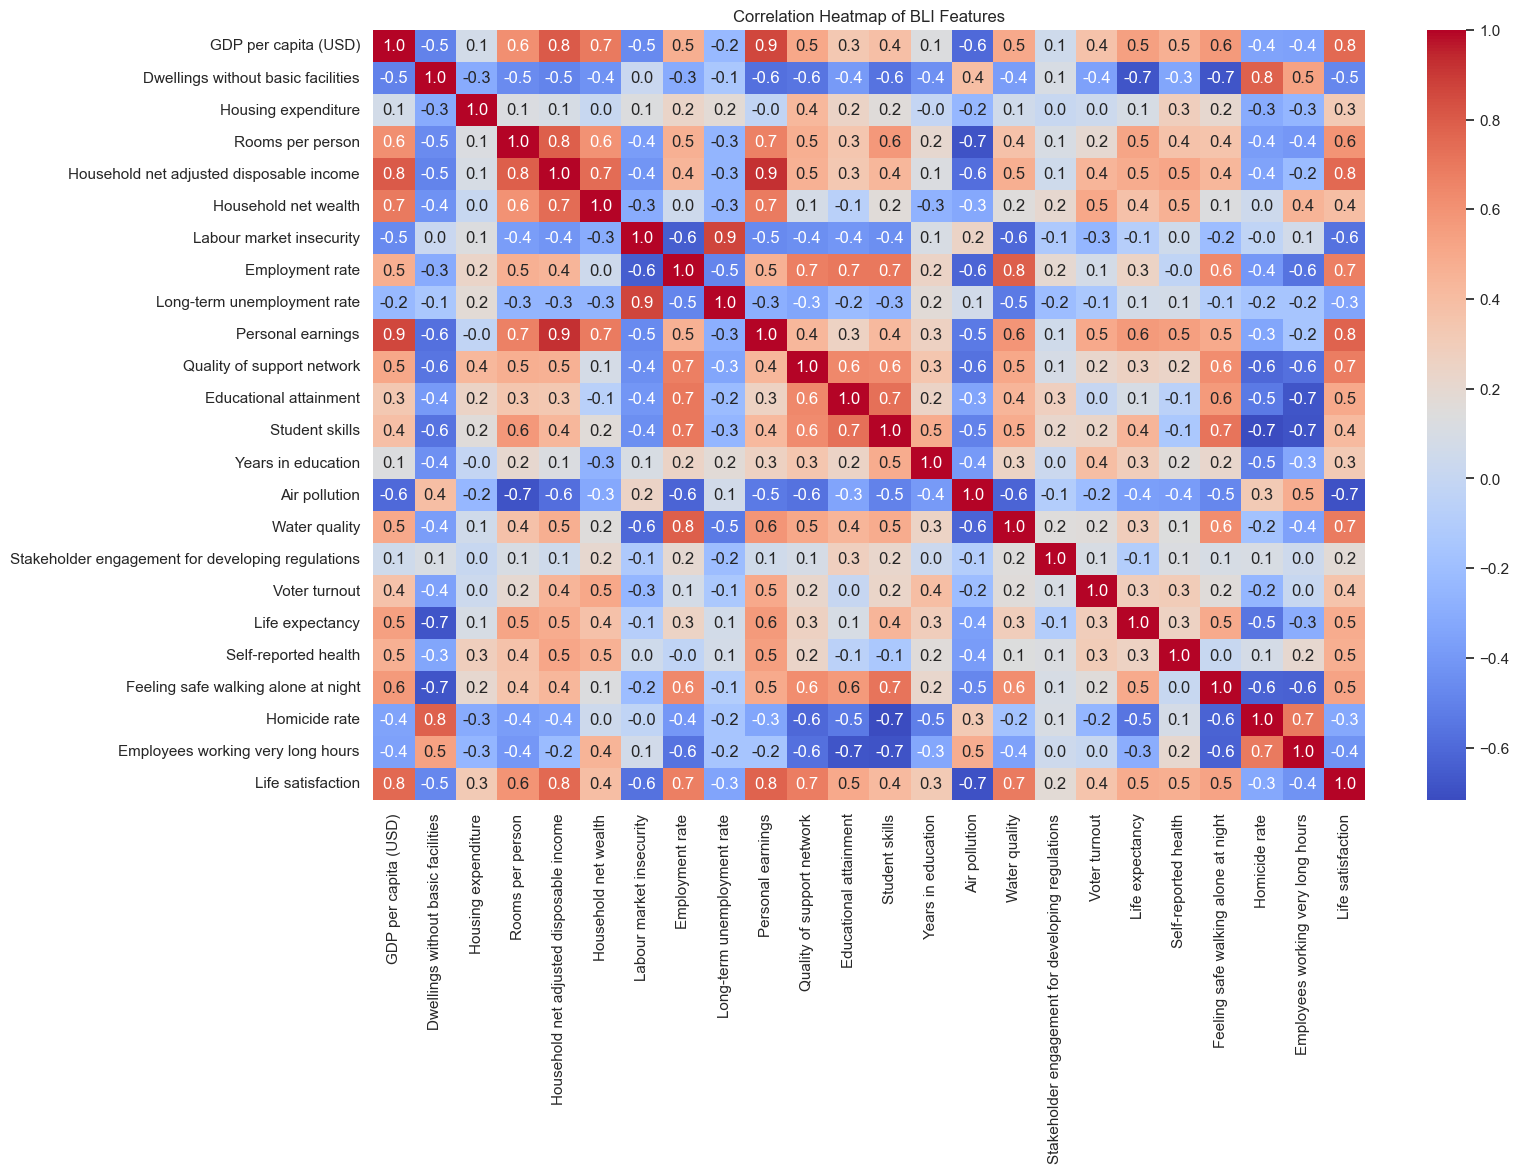

Features most correlated with Life Satisfaction:
Personal earnings                                    0.772145
Household net adjusted disposable income             0.758496
GDP per capita (USD)                                 0.753770
Air pollution                                       -0.690814
Water quality                                        0.686972
Quality of support network                           0.682730
Employment rate                                      0.675973
Rooms per person                                     0.597522
Labour market insecurity                            -0.564118
Feeling safe walking alone at night                  0.529221
Educational attainment                               0.499092
Life expectancy                                      0.483781
Dwellings without basic facilities                  -0.476206
Self-reported health                                 0.476146
Employees working very long hours                   -0.427902
Student skills       

In [12]:
corr_matrix = bli.select_dtypes(include="number").corr()

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=True, fmt=".1f")
plt.title("Correlation Heatmap of BLI Features")
save_plot("correlation_heatmap")
plt.show()

# Correlation with target variable
life_corr = (corr_matrix["Life satisfaction"]
    .drop("Life satisfaction")
    .sort_values(key=abs, ascending=False)
)

print("Features most correlated with Life Satisfaction:")
print(life_corr)

The following variables show the strongest correlation with Life satisfaction:

Positive correlation:
- Personal earnings
- Household net adjusted disposable income
- GDP per capita (USD)
- Water quality
- Quality of support network

Negative correlation:
- Air pollution
- Labour market insecurity
- Dwellings without basic facilities

These relationships suggest that both economic prosperity and environmental/social factors contribute to well-being.

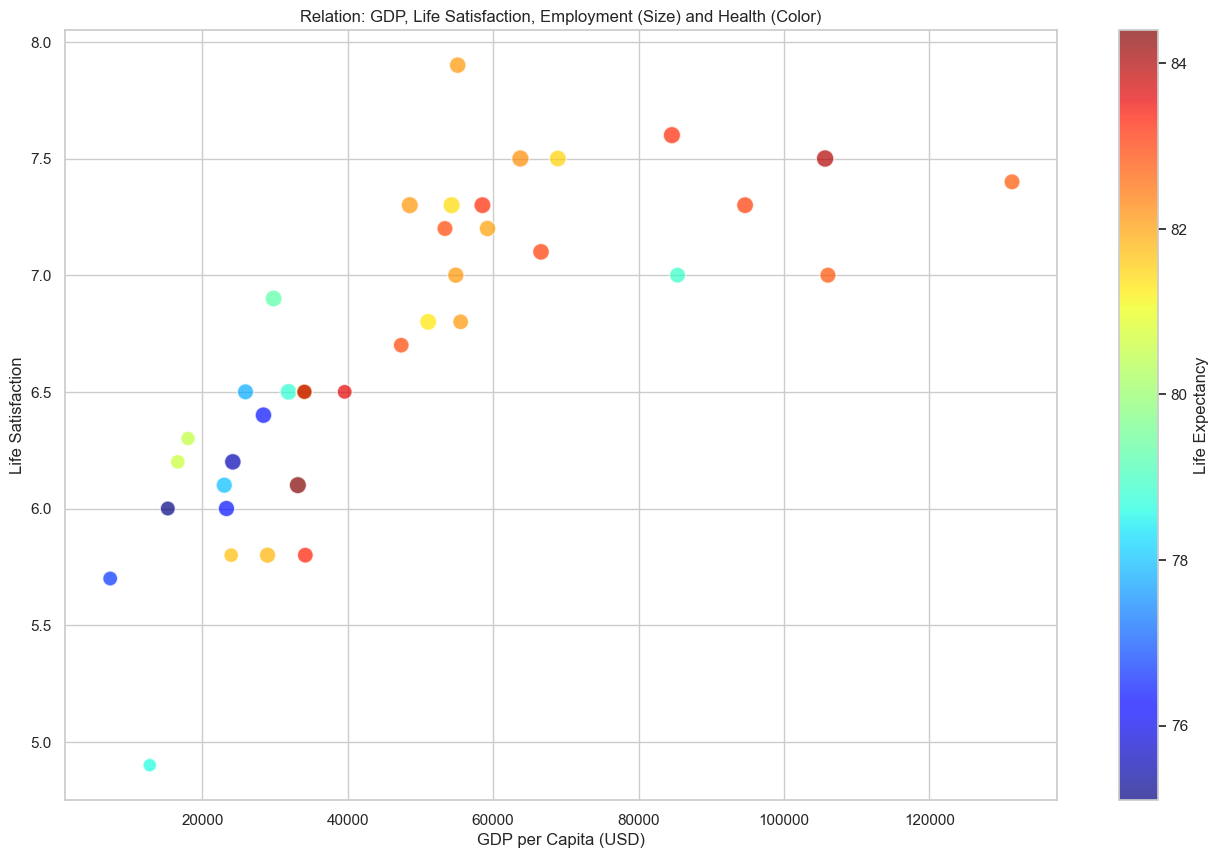

In [ ]:
plt.figure(figsize=(16, 10))

scatter = plt.scatter(
    bli["GDP per capita (USD)"],
    bli["Life satisfaction"],
    s=bli["Employment rate"] * 2,
    c=bli["Life expectancy"],
    cmap="jet",
    alpha=0.7,
    edgecolors="white"
)

plt.colorbar(scatter, label="Life Expectancy")
plt.xlabel("GDP per Capita (USD)")
plt.ylabel("Life Satisfaction")
plt.title("Relation: GDP, Life Satisfaction, Employment (Size) and Health (Color)")
plt.savefig(f"{figures_path}/gdp_life_satisfaction.png")
plt.show()

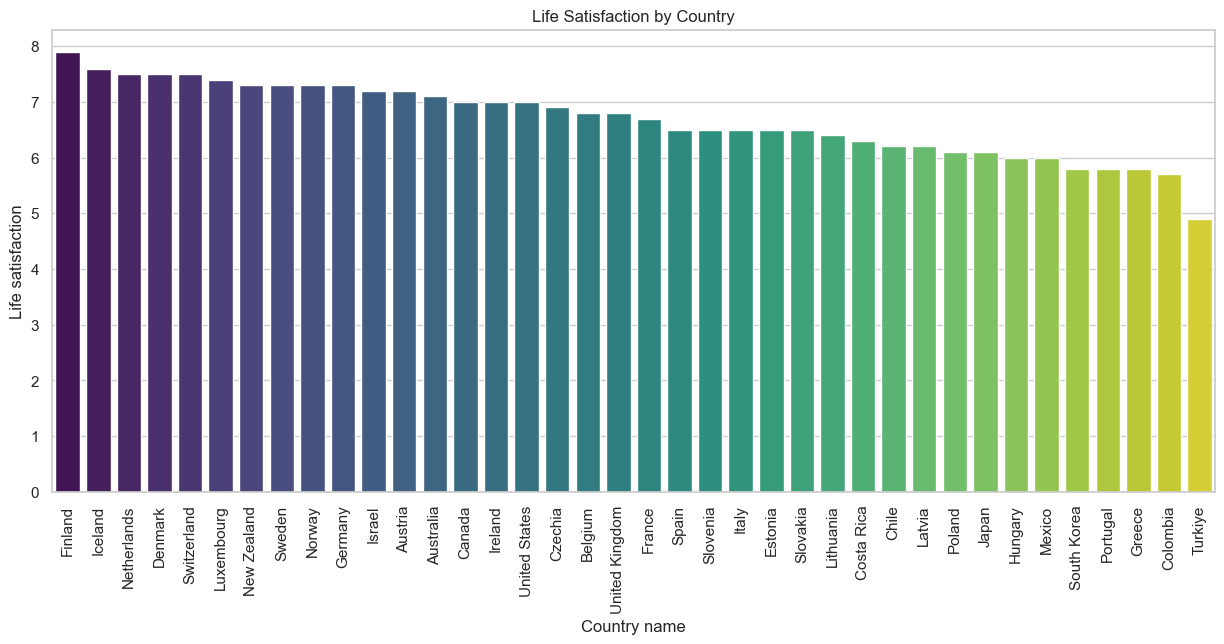

In [13]:
df_sorted = bli.sort_values("Life satisfaction", ascending=False)

plt.figure(figsize=(15, 6))

sns.barplot(
    x="Country name",
    y="Life satisfaction",
    hue="Country name",
    data=df_sorted,
    palette="viridis",
    legend=False
)

plt.xticks(rotation=90)
plt.title("Life Satisfaction by Country")
save_plot("country_life_satisfaction_barplot")
plt.show()

In [34]:
fig = px.choropleth(
    bli,
    locations="Country name",
    locationmode="country names",
    color="Life satisfaction",
    hover_name="Country name",
    hover_data=["GDP per capita (USD)", "Employment rate"],
    color_continuous_scale="Plasma",
    title="Global Life Satisfaction (OECD Better Life Index)"
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0}
)

fig.show()

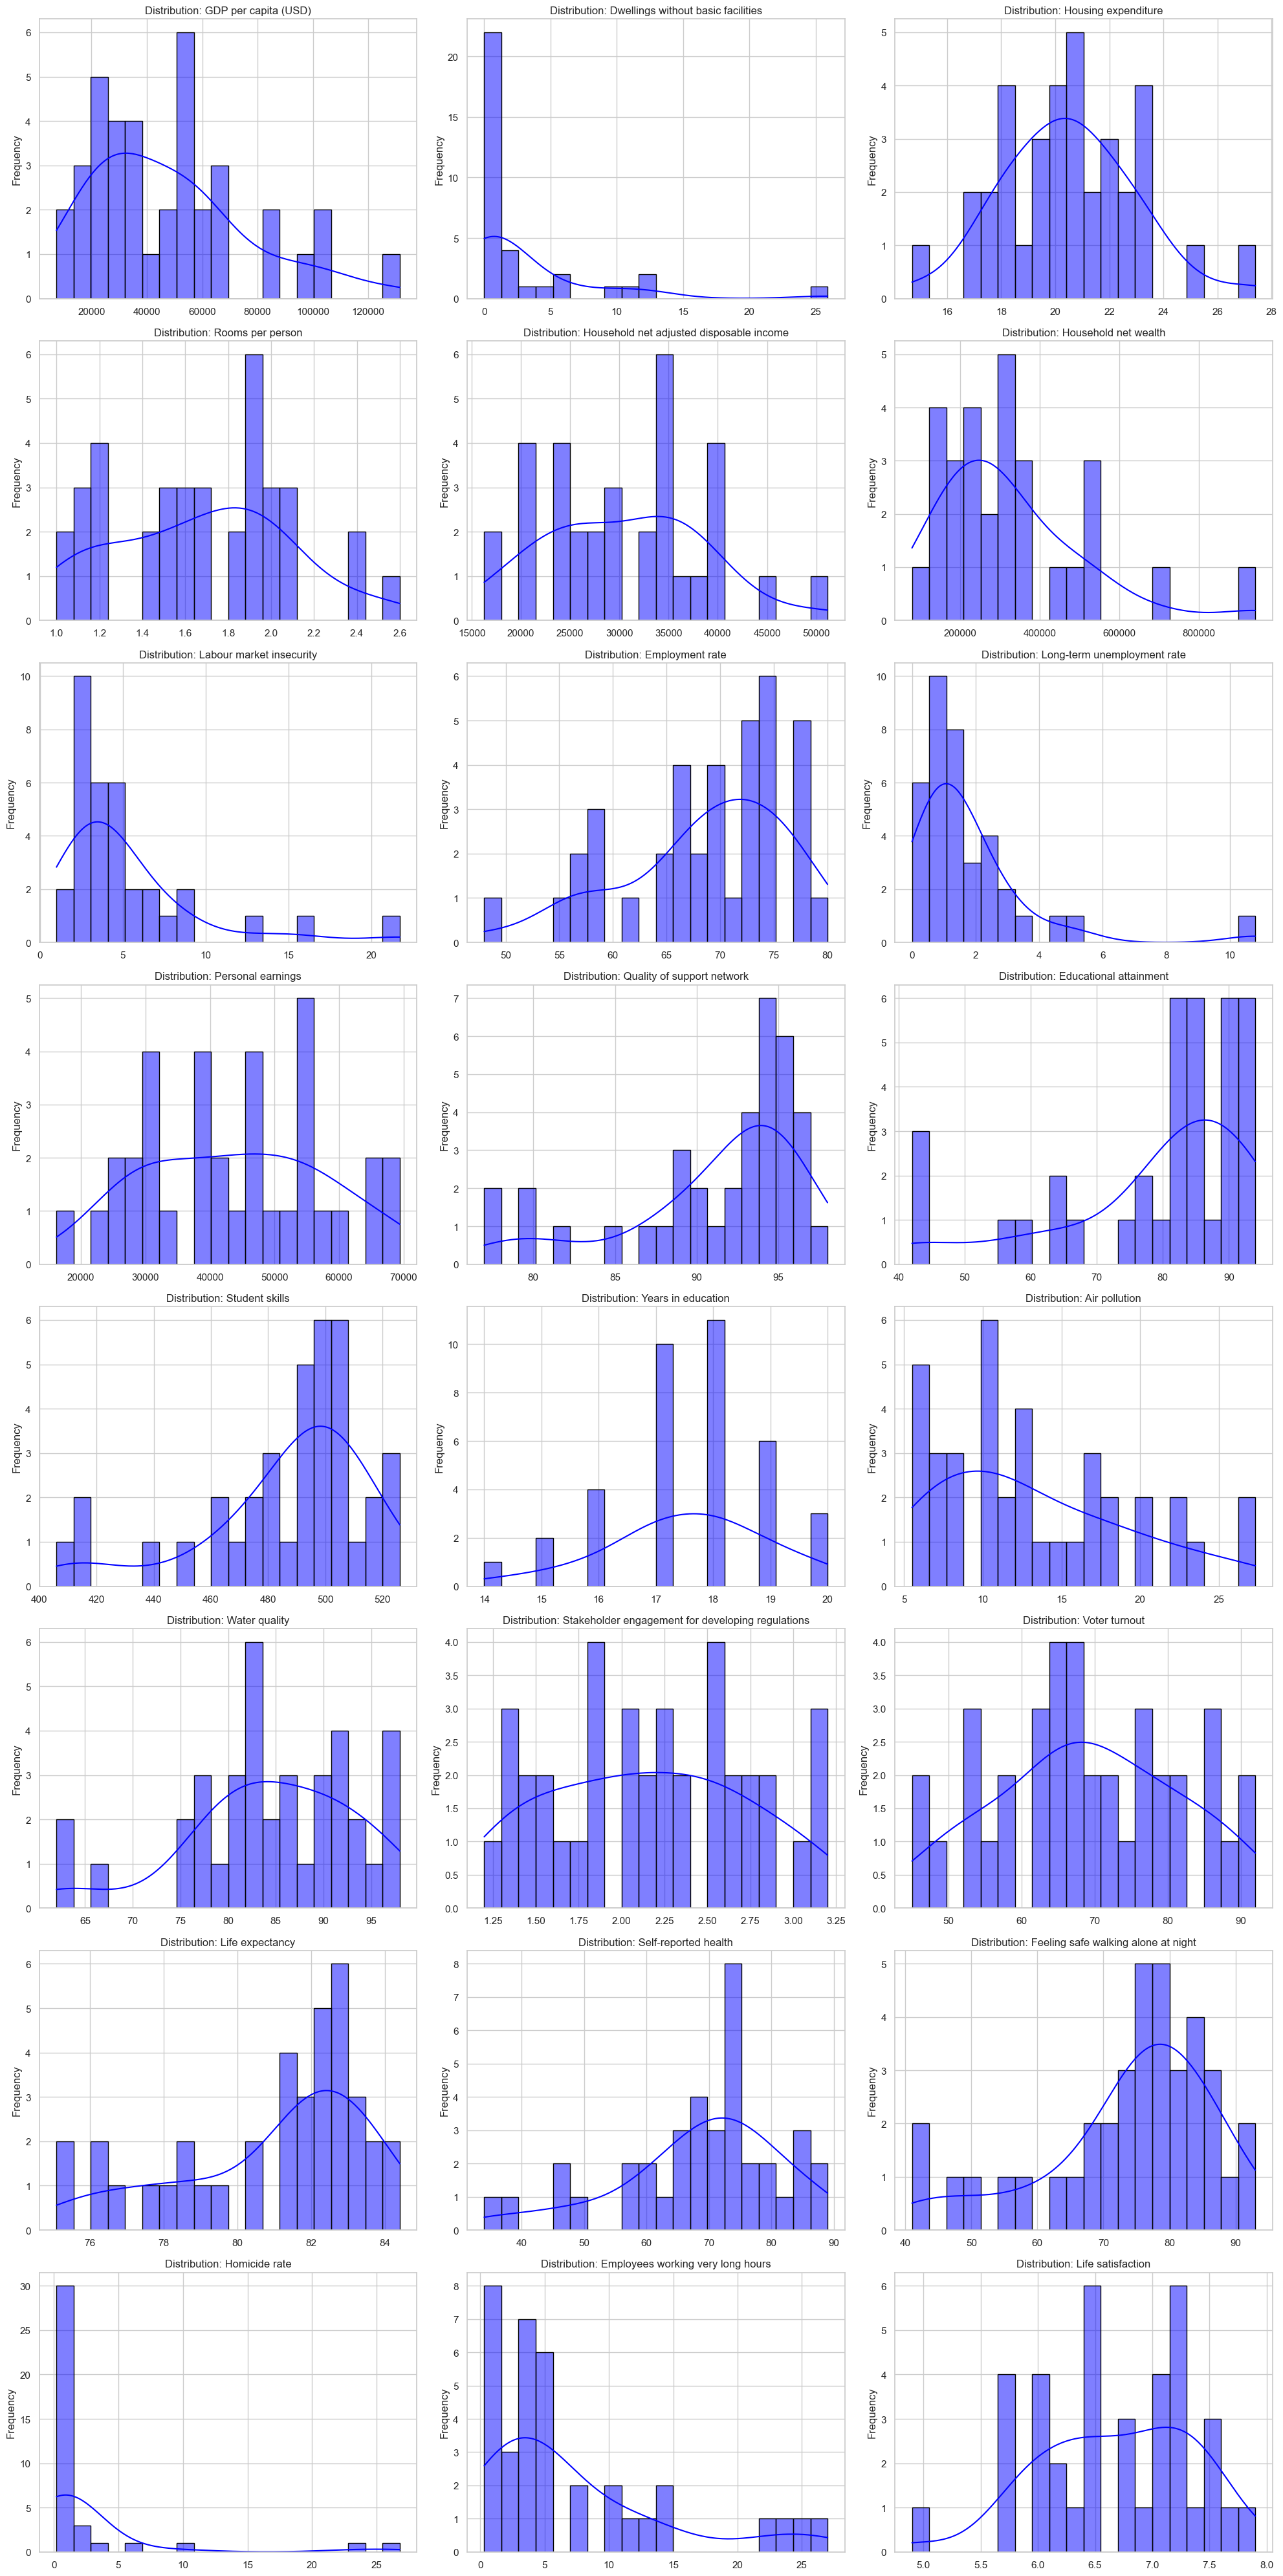

In [14]:
numeric_features = bli.select_dtypes(include="number").columns

n_cols = 3
n_rows = math.ceil(len(numeric_features) / n_cols)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axs = axs.flatten()

for i, col in enumerate(numeric_features):

    sns.histplot(
        bli[col],
        bins=20,
        kde=True,
        ax=axs[i],
        color="blue",
        edgecolor="black"
    )

    axs[i].set_title(f"Distribution: {col}")
    axs[i].set_xlabel("")
    axs[i].set_ylabel("Frequency")

for j in range(len(numeric_features), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
save_plot("feature_distributions")
plt.show()

In [18]:
whr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 11 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country name                                143 non-null    object 
 1   Ladder score                                143 non-null    float64
 2   upperwhisker                                143 non-null    float64
 3   lowerwhisker                                143 non-null    float64
 4   Explained by: Log GDP per capita            140 non-null    float64
 5   Explained by: Social support                140 non-null    float64
 6   Explained by: Healthy life expectancy       140 non-null    float64
 7   Explained by: Freedom to make life choices  140 non-null    float64
 8   Explained by: Generosity                    140 non-null    float64
 9   Explained by: Perceptions of corruption     140 non-null    float64
 10  Dystopia + res

In [19]:
missing_percent = (whr.isnull().sum() / len(bli)) * 100
print("Missing values (%)")
print(missing_percent)

Missing values (%)
Country name                                  0.000000
Ladder score                                  0.000000
upperwhisker                                  0.000000
lowerwhisker                                  0.000000
Explained by: Log GDP per capita              7.894737
Explained by: Social support                  7.894737
Explained by: Healthy life expectancy         7.894737
Explained by: Freedom to make life choices    7.894737
Explained by: Generosity                      7.894737
Explained by: Perceptions of corruption       7.894737
Dystopia + residual                           7.894737
dtype: float64


In [4]:
whr.describe()

,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,143.000000,143.000000,143.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.527580,5.641175,5.413972,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.170717,1.155008,1.187133,0.425098,0.333317,0.164923,0.162492,0.073441,0.126238,0.537459
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.726000,4.845500,4.606000,1.077750,0.921750,0.398000,0.527500,0.091000,0.068750,1.308250
50%,5.785000,5.895000,5.674000,1.431500,1.237500,0.549500,0.641000,0.136500,0.120500,1.644500
75%,6.416000,6.507500,6.319000,1.741500,1.383250,0.648500,0.736000,0.192500,0.193750,1.881750
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


In [23]:
whr["Country name"].unique()

array(['Finland', 'Denmark', 'Iceland', 'Sweden', 'Israel', 'Netherlands',
       'Norway', 'Luxembourg', 'Switzerland', 'Australia', 'New Zealand',
       'Costa Rica', 'Kuwait', 'Austria', 'Canada', 'Belgium', 'Ireland',
       'Czechia', 'Lithuania', 'United Kingdom', 'Slovenia',
       'United Arab Emirates', 'United States', 'Germany', 'Mexico',
       'Uruguay', 'France', 'Saudi Arabia', 'Kosovo', 'Singapore',
       'Taiwan Province of China', 'Romania', 'El Salvador', 'Estonia',
       'Poland', 'Spain', 'Serbia', 'Chile', 'Panama', 'Malta', 'Italy',
       'Guatemala', 'Nicaragua', 'Brazil', 'Slovakia', 'Latvia',
       'Uzbekistan', 'Argentina', 'Kazakhstan', 'Cyprus', 'Japan',
       'South Korea', 'Philippines', 'Vietnam', 'Portugal', 'Hungary',
       'Paraguay', 'Thailand', 'Malaysia', 'China', 'Honduras', 'Bahrain',
       'Croatia', 'Greece', 'Bosnia and Herzegovina', 'Libya', 'Jamaica',
       'Peru', 'Dominican Republic', 'Mauritius', 'Moldova', 'Russia',
       'Boli